In [43]:
import pandas as pd
from bs4 import BeautifulSoup
import string
import warnings
warnings.filterwarnings("ignore")

In [44]:
df=pd.read_csv('./data/IMDB Dataset.csv')

In [45]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [46]:
df.shape

(50000, 2)

In [47]:
df['sentiment'].value_counts()

sentiment
positive    25000
negative    25000
Name: count, dtype: int64

In [48]:
def text_cleaning(text):
    text=BeautifulSoup(text,"html.parser").get_text()
    text=text.lower()
    text = text.translate(str.maketrans('', '', string.punctuation))
    return text

In [49]:
df['review']=df['review'].apply(text_cleaning)

In [50]:
df.head()

,review,sentiment
0,one of the other reviewers has mentioned that ...,positive
1,a wonderful little production the filming tech...,positive
2,i thought this was a wonderful way to spend ti...,positive
3,basically theres a family where a little boy j...,negative
4,petter matteis love in the time of money is a ...,positive


In [51]:
from sklearn.preprocessing import LabelEncoder

le=LabelEncoder()

df['sentiment']=le.fit_transform(df['sentiment'])

In [69]:
from sklearn.model_selection import train_test_split

x=df['review']
y=df['sentiment']
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [70]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import  pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding,SimpleRNN,Dense,LSTM,GRU,Dropout

In [71]:
tokenizer=Tokenizer(num_words=10000)
tokenizer.fit_on_texts(x_train)

x_train_seq=tokenizer.texts_to_sequences(x_train)
x_test_seq=tokenizer.texts_to_sequences(x_test)

In [75]:
max_len=200
x_train_pad=pad_sequences(x_train_seq,maxlen=max_len)
x_test_pad=pad_sequences(x_test_seq,maxlen=max_len)

In [76]:
print(len(x_train_pad))
print(len(y_train))

40000
40000


In [77]:
print(x_train_pad.shape)
print(y_train.shape)

(40000, 200)
(40000,)


In [84]:
model=Sequential()

model.add(Embedding(input_dim=10000,output_dim=64,input_length=max_len))
model.add(SimpleRNN(64))
model.add(Dense(1,activation='sigmoid'))


In [85]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_3 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [86]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [87]:
history=model.fit(x_train_pad,y_train,epochs=5,batch_size=64,validation_data=(x_test_pad,y_test))

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 14s 20ms/step - accuracy: 0.7572 - loss: 0.4893 - val_accuracy: 0.8409 - val_loss: 0.3795
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 16s 26ms/step - accuracy: 0.8303 - loss: 0.3859 - val_accuracy: 0.8355 - val_loss: 0.4122
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 19s 30ms/step - accuracy: 0.8532 - loss: 0.3512 - val_accuracy: 0.8256 - val_loss: 0.4144
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 14s 23ms/step - accuracy: 0.8938 - loss: 0.2702 - val_accuracy: 0.8253 - val_loss: 0.4049
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 14s 22ms/step - accuracy: 0.9195 - loss: 0.2118 - val_accuracy: 0.8331 - val_loss: 0.4527


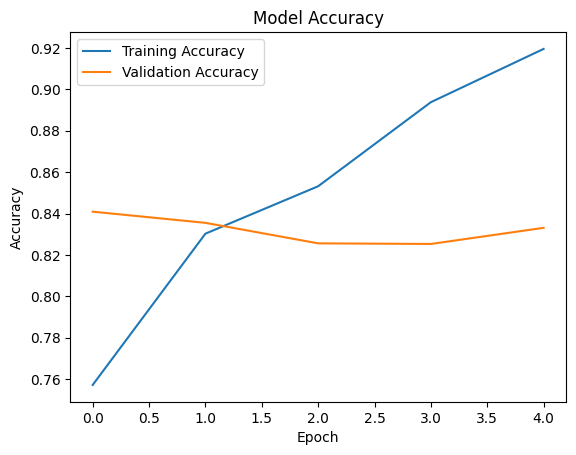

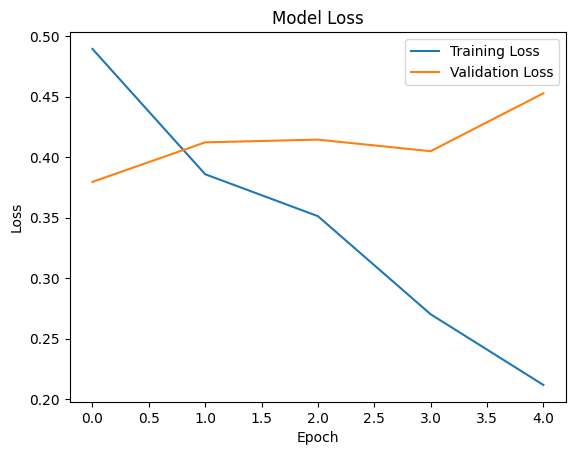

In [89]:
import matplotlib.pyplot as plt

# Accuracy plot
plt.figure()

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Model Accuracy')

plt.legend()
plt.show()


# Loss plot
plt.figure()

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Model Loss')

plt.legend()
plt.show()

In [90]:
sentence = ["it was good movie"]

# convert to sequence
seq = tokenizer.texts_to_sequences(sentence)

# pad sequence
pad = pad_sequences(seq, maxlen=200)

# prediction
prediction = model.predict(pad)

print(prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step
[[0.18355091]]
